In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# ==========================================
# PART A: DATA PREPARATION (Handled Separately)
# ==========================================

print("--- PROCESSING DATASET 1: TRADES ---")
# 1. Load historical trades data
trades = pd.read_csv('historical_data.csv')

# Document initial state
print("Trades Dataset Shape:", trades.shape)
print("Trades Missing Values:\n", trades.isnull().sum())
print("Trades Duplicates:", trades.duplicated().sum())

--- PROCESSING DATASET 1: TRADES ---
Trades Dataset Shape: (211224, 16)
Trades Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Trades Duplicates: 0


In [3]:
# Convert timestamp (assuming format 'DD-MM-YYYY HH:MM' based on inspection)
# Create a standard 'Date' column for daily-level alignment
trades['Date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
trades['Date'] = pd.to_datetime(trades['Date'])

# Create basic trade metrics per row
trades['Win'] = (trades['Closed PnL'] > 0).astype(int)
trades['Is_Trade'] = 1
trades['Is_Long'] = trades['Direction'].isin(['Buy', 'Open Long', 'Close Long'])
trades['Is_Short'] = trades['Direction'].isin(['Sell', 'Open Short', 'Close Short'])


In [4]:
print("\n--- PROCESSING DATASET 2: FEAR & GREED INDEX ---")
fgi = pd.read_csv('fear_greed_index.csv')

# Document initial state
print("FGI Dataset Shape:", fgi.shape)
print("FGI Missing Values:\n", fgi.isnull().sum())
print("FGI Duplicates:", fgi.duplicated().sum())

# Convert date to standard datetime
fgi['Date'] = pd.to_datetime(fgi['date'])

# Simplify classification into 3 main buckets
def simplify_sentiment(x):
    if 'Fear' in x: return 'Fear'
    elif 'Greed' in x: return 'Greed'
    return 'Neutral'

fgi['Sentiment'] = fgi['classification'].apply(simplify_sentiment)


--- PROCESSING DATASET 2: FEAR & GREED INDEX ---
FGI Dataset Shape: (2644, 4)
FGI Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
FGI Duplicates: 0


In [5]:
print("\n--- ALIGNING & MERGING DATASETS ---")
# 3. Align the datasets by Date (Daily level)
df = trades.merge(fgi[['Date', 'value', 'Sentiment']], on='Date', how='inner')
print("Merged Dataset Shape:", df.shape)


--- ALIGNING & MERGING DATASETS ---
Merged Dataset Shape: (211218, 23)


In [6]:
# ==========================================
# PART B: ANALYSIS & SEGMENTATION
# ==========================================

print("\n--- 1. PERFORMANCE DIFFERENCES (FEAR VS GREED) ---")
# Filter to only trades that were closed (where PnL was realized)
closing_trades = df[df['Closed PnL'] != 0]

sentiment_perf = closing_trades.groupby('Sentiment').agg(
    Total_PnL=('Closed PnL', 'sum'),
    Avg_PnL=('Closed PnL', 'mean'),
    Win_Rate=('Win', 'mean'),
    Trade_Count=('Closed PnL', 'count')
).reset_index()
print(sentiment_perf)


--- 1. PERFORMANCE DIFFERENCES (FEAR VS GREED) ---
  Sentiment     Total_PnL     Avg_PnL  Win_Rate  Trade_Count
0      Fear  4.096266e+06  101.861682  0.844233        40214
1     Greed  4.865301e+06  105.700767  0.824524        46029
2   Neutral  1.292921e+06   71.199993  0.823889        18159


In [7]:
print("\n--- 2. BEHAVIORAL CHANGES BY SENTIMENT ---")
# Calculate daily trades per sentiment to find average trade frequency
daily_trades = df.groupby(['Date', 'Sentiment']).size().reset_index(name='Daily_Trades')
avg_daily_freq = daily_trades.groupby('Sentiment')['Daily_Trades'].mean().reset_index(name='Avg_Trades_Per_Day')

behavior_stats = df.groupby('Sentiment').agg(
    Avg_Size_USD=('Size USD', 'mean'),
    Total_Volume_USD=('Size USD', 'sum')
).reset_index()

# Long/Short bias
ls_ratio = df.groupby('Sentiment').agg(Longs=('Is_Long', 'sum'), Shorts=('Is_Short', 'sum'))
ls_ratio['L/S_Ratio'] = ls_ratio['Longs'] / ls_ratio['Shorts']

behavior_summary = behavior_stats.merge(avg_daily_freq, on='Sentiment').merge(ls_ratio, on='Sentiment')
print(behavior_summary)


--- 2. BEHAVIORAL CHANGES BY SENTIMENT ---
  Sentiment  Avg_Size_USD  Total_Volume_USD  Avg_Trades_Per_Day  Longs  \
0      Fear   7182.011019      5.978091e+08          792.733333  52344   
1     Greed   4574.424490      4.130477e+08          294.120521  39845   
2   Neutral   4782.732661      1.802421e+08          562.477612  23100   

   Shorts  L/S_Ratio  
0   30805   1.699205  
1   50296   0.792210  
2   14549   1.587738  


In [8]:
print("\n--- 3. TRADER SEGMENTATION ---")


# Group by account to get behavioral features
trader_features = df.groupby('Account').agg(
    Total_Trades=('Is_Trade', 'count'),
    Avg_Size_USD=('Size USD', 'mean'),
    Win_Rate=('Win', 'mean')
).fillna(0)

# Standardize the features for ML
scaler = StandardScaler()
scaled_features = scaler.fit_transform(trader_features)

# Apply K-Means Clustering (3 Archetypes)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_features['Archetype_Cluster'] = kmeans.fit_predict(scaled_features)

# Name the clusters based on their characteristics (e.g., Retail, Whales, High-Frequency)
print(trader_features.groupby('Archetype_Cluster').mean())

# Segment traders by historical activity
account_stats = df.groupby('Account').agg(
    Total_Trades=('Is_Trade', 'count'),
    Avg_Size_USD=('Size USD', 'mean'),
    Total_PnL=('Closed PnL', 'sum')
).reset_index()

# Define segments based on medians
median_trades = account_stats['Total_Trades'].median()
account_stats['Frequency_Segment'] = np.where(account_stats['Total_Trades'] > median_trades, 'Frequent', 'Infrequent')

# Merge segments back to main dataframe
df = df.merge(account_stats[['Account', 'Frequency_Segment']], on='Account')

# Analyze how Frequent vs Infrequent traders perform in different sentiments
segment_behavior = df.groupby(['Frequency_Segment', 'Sentiment']).agg(
    Total_PnL=('Closed PnL', 'sum'),
    Avg_Size=('Size USD', 'mean')
).reset_index()
print(segment_behavior)


--- 3. TRADER SEGMENTATION ---
                   Total_Trades  Avg_Size_USD  Win_Rate
Archetype_Cluster                                      
0                  20003.833333   1915.636756  0.379881
1                   7119.000000  22539.720976  0.389945
2                   2850.863636   4115.807187  0.411637
  Frequency_Segment Sentiment     Total_PnL     Avg_Size
0          Frequent      Fear  3.431836e+06  7563.359761
1          Frequent     Greed  3.339075e+06  4643.231399
2          Frequent   Neutral  1.173531e+06  4780.761654
3        Infrequent      Fear  6.644298e+05  4602.874290
4        Infrequent     Greed  1.526225e+06  4008.612410
5        Infrequent   Neutral  1.193894e+05  4800.574775


C:\Users\Chirag\AppData\Local\Temp\ipykernel_12656\2344614571.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_perf, x='Sentiment', y='Win_Rate', palette='viridis')


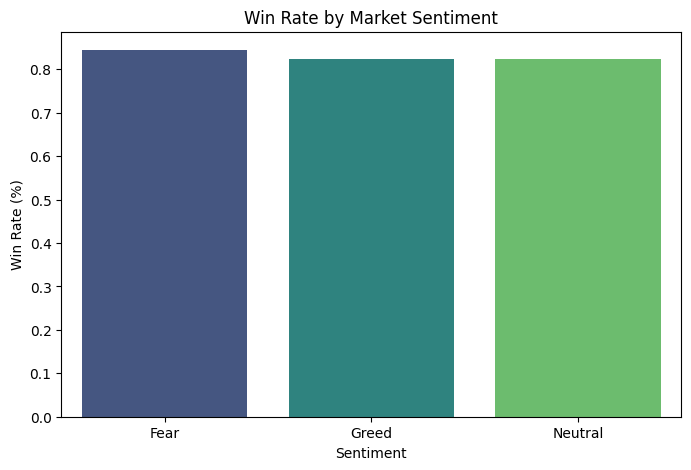

C:\Users\Chirag\AppData\Local\Temp\ipykernel_12656\2344614571.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=behavior_summary, x='Sentiment', y='Avg_Size_USD', palette='magma')


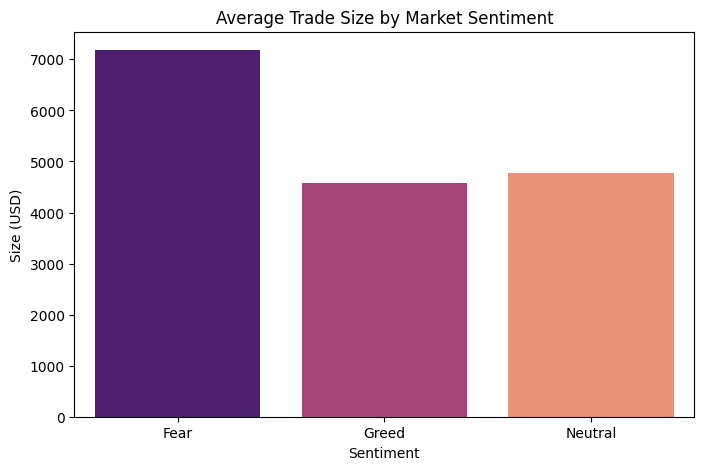

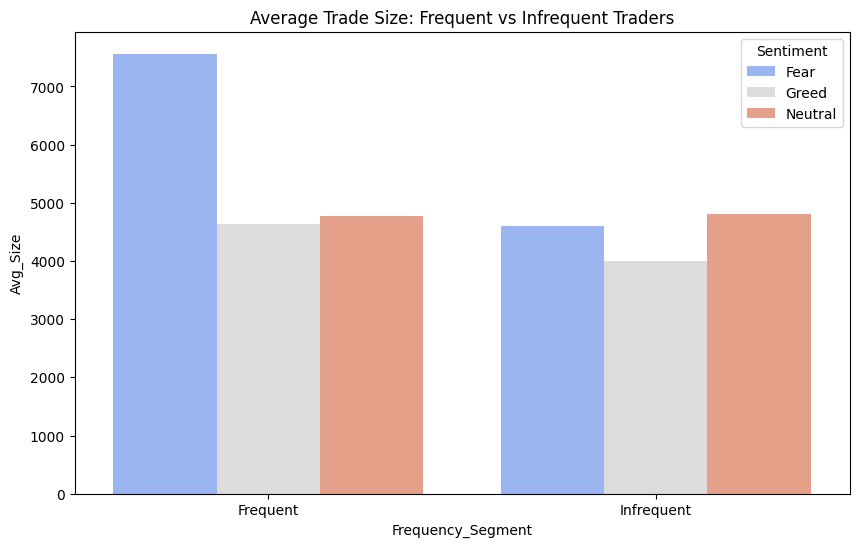

In [9]:
# --- CHART GENERATION ---
# 1. Win Rate Chart
plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_perf, x='Sentiment', y='Win_Rate', palette='viridis')
plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

# 2. Average Trade Size Chart
plt.figure(figsize=(8,5))
sns.barplot(data=behavior_summary, x='Sentiment', y='Avg_Size_USD', palette='magma')
plt.title('Average Trade Size by Market Sentiment')
plt.ylabel('Size (USD)')
plt.show()

# 3. Segment Behavior Chart
plt.figure(figsize=(10,6))
sns.barplot(data=segment_behavior, x='Frequency_Segment', y='Avg_Size', hue='Sentiment', palette='coolwarm')
plt.title('Average Trade Size: Frequent vs Infrequent Traders')
plt.show()

In [10]:
print("\n--- BONUS: PREDICTING TRADE PROFITABILITY ---")
# Can we predict if a trade will be a Win (1) or Loss (0)?
# Features: FGI Value, Size USD, Is_Long flag
ml_df = df[df['Closed PnL'] != 0].dropna(subset=['value', 'Size USD', 'Is_Long', 'Win'])

X = ml_df[['value', 'Size USD', 'Is_Long']]  # 'value' is the exact Fear/Greed index score
y = ml_df['Win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification Report for Predicting Trade Win/Loss:")
print(classification_report(y_test, y_pred))


--- BONUS: PREDICTING TRADE PROFITABILITY ---
Classification Report for Predicting Trade Win/Loss:
              precision    recall  f1-score   support

           0       0.21      0.66      0.32      3513
           1       0.88      0.50      0.63     17368

    accuracy                           0.52     20881
   macro avg       0.54      0.58      0.47     20881
weighted avg       0.76      0.52      0.58     20881

